<a href="https://colab.research.google.com/github/tejas1824/CSL701-Roll_No30_Machine-Learning-Lab/blob/main/tejasexp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tejas Mochemadkar
CE30

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


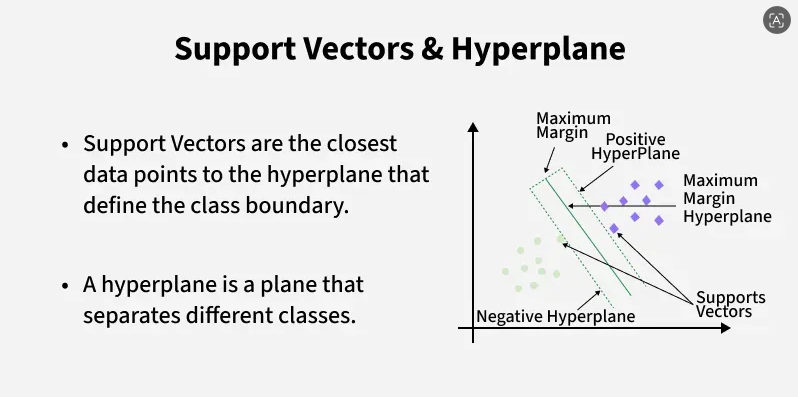
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

# Download the Iris dataset and save it as 'Iris.csv'
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
urllib.request.urlretrieve(url, 'Iris.csv')

# Load the dataset using the specified file name
df = pd.read_csv('Iris.csv')

# Display the first few rows to verify
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


# Task 2: Explore the Dataset

In [ ]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display basic information about columns and types
print("\nDataset Info:")
df.info()

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Class distribution
print("\nClass distribution:")
print(df['variety'].value_counts())

Dataset Shape: (150, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Summary Statistics:
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Select features and target
# If 'Id' were present, we would drop it; we'll write a safe drop in case other datasets are used.
if 'Id' in df.columns:
    X = df.drop(columns=['Id', 'variety'])
else:
    X = df.drop(columns=['variety'])

y = df['variety']

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)
print("\nFirst 5 rows of features:")
print(X.head())

Features (X) Shape: (150, 4)
Target (y) Shape: (150,)

First 5 rows of features:
   sepal.length  sepal.width  petal.length  petal.width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = svm_model.predict(X_test_scaled)

print("Linear SVM model has been trained successfully.")
print("Predictions made on test dataset.")

Linear SVM model has been trained successfully.
Predictions made on test dataset.


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

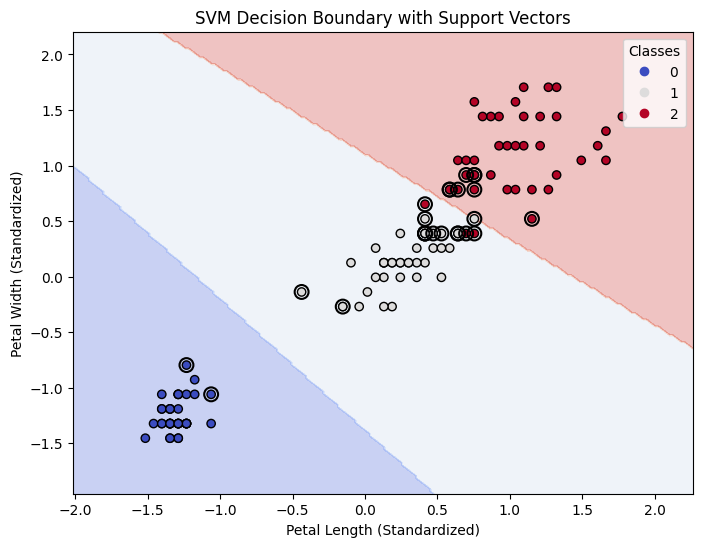

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Create the 2-D Dataset
X_2d = df[['petal.length', 'petal.width']]
y_2d = df['variety']

# Map target species to integers for easier visualization plotting
species_map = {'Setosa': 0, 'Versicolor': 1, 'Virginica': 2}
y_2d_encoded = y_2d.map(species_map)

# 2. Split the Data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d_encoded, test_size=0.2, random_state=42, stratify=y_2d_encoded
)

# 3. Scale the Data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 4. Train SVM
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# 5. Plot Decision Boundary
def plot_decision_boundary(model, X_scaled, y, title, scaler):
    # Create a mesh grid
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Make predictions on the grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Scatter plot of training points
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)

    # Highlight Support Vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

    plt.xlabel('Petal Length (Standardized)')
    plt.ylabel('Petal Width (Standardized)')
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

plot_decision_boundary(svm_2d, X_train_2d_scaled, y_train_2d, "SVM Decision Boundary with Support Vectors", scaler_2d)

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

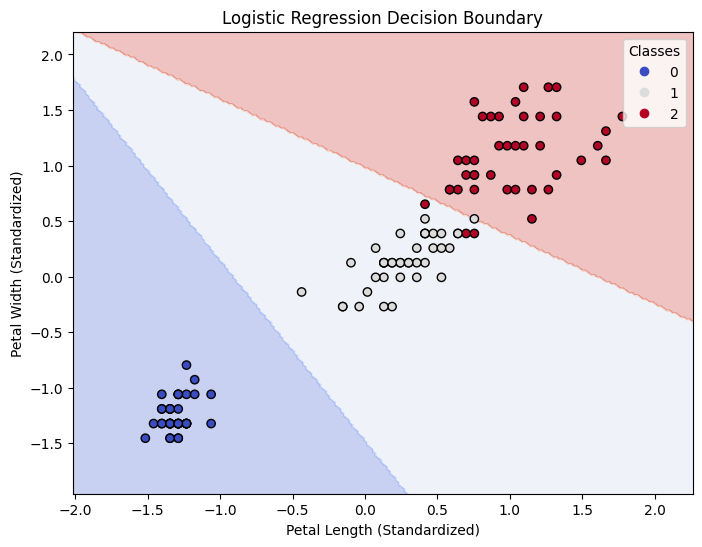

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Train Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_2d_scaled, y_train_2d)

# 2. Visualize Decision Boundary for Logistic Regression
def plot_logistic_boundary(model, X_scaled, y, title):
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)

    plt.xlabel('Petal Length (Standardized)')
    plt.ylabel('Petal Width (Standardized)')
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

plot_logistic_boundary(log_reg_model, X_train_2d_scaled, y_train_2d, "Logistic Regression Decision Boundary")

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

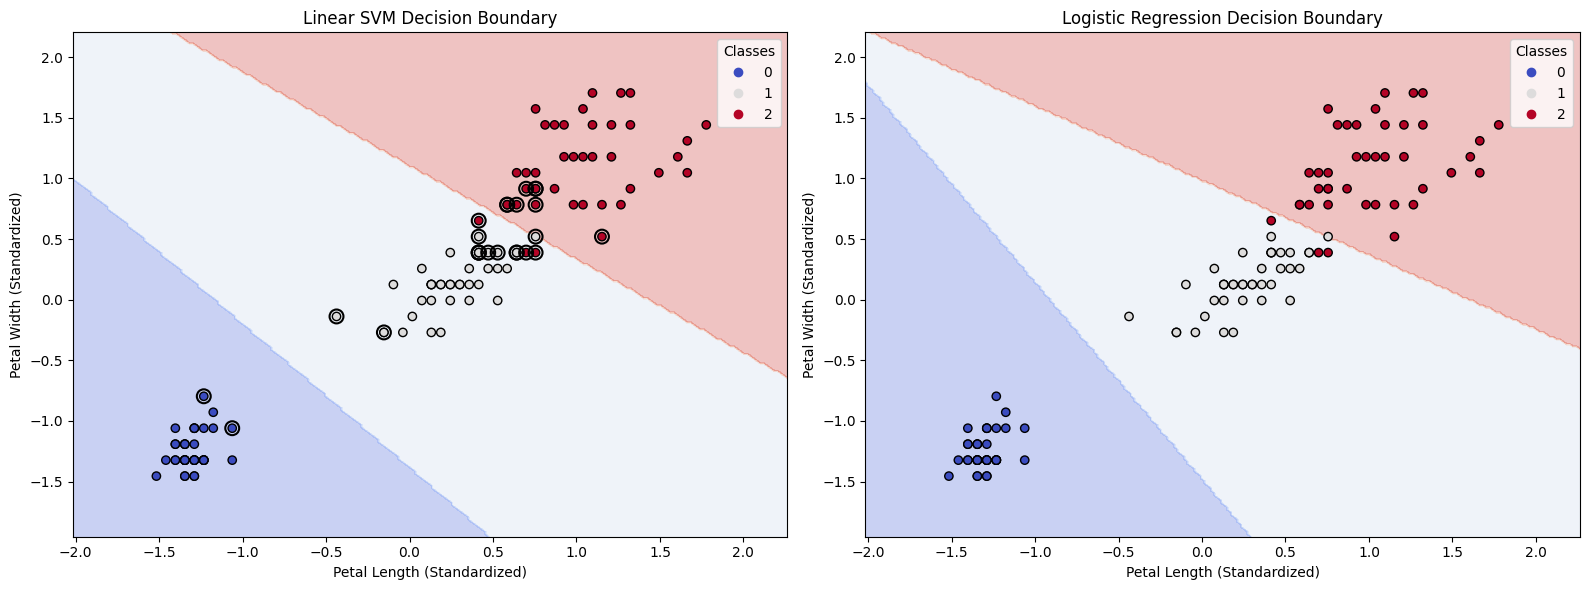

In [ ]:
# Task 9: Compare SVM and Normal Boundary

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_min, x_max = X_train_2d_scaled[:, 0].min() - 0.5, X_train_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_2d_scaled[:, 1].min() - 0.5, X_train_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 1. Plot SVM Boundary
Z_svm = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_svm, alpha=0.3, cmap=plt.cm.coolwarm)
scatter_svm = axes[0].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')
axes[0].set_xlabel('Petal Length (Standardized)')
axes[0].set_ylabel('Petal Width (Standardized)')
axes[0].set_title("Linear SVM Decision Boundary")
axes[0].legend(*scatter_svm.legend_elements(), title="Classes")

# 2. Plot Logistic Regression Boundary
Z_lr = log_reg_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.coolwarm)
scatter_lr = axes[1].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_xlabel('Petal Length (Standardized)')
axes[1].set_ylabel('Petal Width (Standardized)')
axes[1].set_title("Logistic Regression Decision Boundary")
axes[1].legend(*scatter_lr.legend_elements(), title="Classes")

plt.tight_layout()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Predictions for 2D Models on the Test Set
y_pred_svm_2d = svm_2d.predict(X_test_2d_scaled)
y_pred_lr_2d = log_reg_model.predict(X_test_2d_scaled)

# 2. Performance Metrics for Linear SVM (2D)
print("=================== LINEAR SVM (2D) PERFORMANCE ===================")
print(f"Accuracy: {accuracy_score(y_test_2d, y_pred_svm_2d):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2d, y_pred_svm_2d))
print("\nClassification Report:")
print(classification_report(y_test_2d, y_pred_svm_2d, target_names=['Setosa', 'Versicolor', 'Virginica']))

# 3. Performance Metrics for Logistic Regression (2D)
print("\n=============== LOGISTIC REGRESSION (2D) PERFORMANCE =============")
print(f"Accuracy: {accuracy_score(y_test_2d, y_pred_lr_2d):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2d, y_pred_lr_2d))
print("\nClassification Report:")
print(classification_report(y_test_2d, y_pred_lr_2d, target_names=['Setosa', 'Versicolor', 'Virginica']))

=================== LINEAR SVM (2D) PERFORMANCE ===================
Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=============== LOGISTIC REGRESSION (2D) PERFORMANCE =============
Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg     

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.